# Ejercicio 3 - Índices NDVI, NDWI y cianobacteria

Este cuaderno calcula, para cada combinación oficial lago-fecha, los tres
índices pedidos en el laboratorio: NDVI, NDWI y el índice de cianobacteria.
Depende de los raster crudos ya descargados (`data/raw/rasters/`, bandas
B03, B04, B08, SCL de Sentinel-2 L2A) y produce el contrato
`manifest_indices.csv` que usa el ejercicio 4.

Por defecto el cuaderno solo valida configuración y contrato sin descargar ni
calcular nada remoto, igual que el cuaderno de los ejercicios 1 y 2.

## 1. Decisión del script de cianobacteria

El catálogo de https://custom-scripts.sentinel-hub.com tiene varios scripts
relacionados con agua/algas para Sentinel-2 (NDCI L1C, Se2WaQ, Maximum Peak
Height Bloom Index, APA Script). Se eligió **CyanoLakes Chlorophyll-a L1C
(NDCI)** porque:

- Es el único nombrado explícitamente para cianobacteria, no para calidad de
  agua en general.
- Su fórmula, umbrales y máscara de agua son públicos y auditables (no es
  una caja negra): `src/evalscripts/cyano_ndci_l1c_original.js` es una copia
  textual, sin modificar, del script del catálogo.
- Usa Sentinel-2 **L1C** (reflectancia TOA), el producto para el que fue
  calibrado el polinomio de clorofila-a. Por eso **no se reproduce
  localmente sobre L2A**: se pide directamente a la Process API de
  Sentinel Hub / Copernicus Data Space el resultado numérico de ese script
  (decisión explícita del ejercicio 3.1 del enunciado).

`src/evalscripts/cyano_ndci_l1c_numeric.js` es una adaptación fiel del
script original: mismas fórmulas, mismos umbrales y mismas 9 bandas de
entrada; lo único que cambia es la salida, que deja de ser un color RGB de
visualización y pasa a ser un valor numérico FLOAT32 (`chl`), con una banda
`dataMask` que marca como válido únicamente lo que el propio script clasifica
como agua. Esto es necesario porque, como señala el enunciado, "una imagen
RGB coloreada sirve para visualizar, pero no para recuperar de forma válida
el índice promedio".

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Abra Jupyter desde la raíz de Laboratorio 4')

sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src import indices


In [2]:
from src.config import (
    CYANO_SCRIPT,
    ESCENAS_OFICIALES,
    INDICES,
    RESOLUCION_OBJETIVO_M,
)
from src.indices import (
    compute_indices_batch,
    compute_indices_for_scene,
    prepare_indices_repository,
    request_cyano_layer,
    select_scenes,
    validate_manifest_indices,
)

print(f'Raíz del proyecto: {ROOT}')
print(f'Índices a calcular: {INDICES}')
print(f'Resolución objetivo: {RESOLUCION_OBJETIVO_M} m')


Raíz del proyecto: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales
Índices a calcular: ('ndvi', 'ndwi', 'cianobacteria')
Resolución objetivo: 10 m


## 2. Preparación local y contrato de datos

`manifest_indices.csv` nace con 66 filas (22 escenas oficiales x 3 índices)
en estado `pendiente_calculo`. Cada fila se completa únicamente cuando el
índice correspondiente se calcula y exporta con éxito.

In [3]:
summary = prepare_indices_repository()
rows = validate_manifest_indices()
manifest = pd.DataFrame(rows)

print(f"Filas del manifiesto de índices: {summary['rows']}")
display(manifest.groupby(['indice', 'quality_flag']).size().rename('n').reset_index())


Filas del manifiesto de índices: 66


,indice,quality_flag,n
0,cianobacteria,calculado,15
1,cianobacteria,cobertura_parcial_oficial,1
2,cianobacteria,revisar_valores_atipicos,6
3,ndvi,calculado,18
4,ndvi,cobertura_parcial_oficial,1
5,ndvi,revisar_valores_atipicos,3
6,ndwi,calculado,18
7,ndwi,cobertura_parcial_oficial,1
8,ndwi,revisar_valores_atipicos,3


## 3. Fórmulas documentadas

Las mismas fórmulas se usan en `src/indices.py`; aquí solo se muestran para
que queden visibles junto a los resultados.

In [4]:
formulas = pd.Series(
    {
        'NDVI': 'NDVI = (B08 - B04) / (B08 + B04)',
        'NDWI': 'NDWI = (B03 - B08) / (B03 + B08)',
        'Cianobacteria (NDCI)': CYANO_SCRIPT['formula_ndci'],
        'Cianobacteria (chl-a)': CYANO_SCRIPT['formula_chl'],
        'Máscara de agua del script': CYANO_SCRIPT['mascara'],
        'Unidad cianobacteria': CYANO_SCRIPT['unidad'],
        'Script fuente': CYANO_SCRIPT['url_fuente'],
    },
    name='definición',
)
formulas.to_frame()


,definición
NDVI,NDVI = (B08 - B04) / (B08 + B04)
NDWI,NDWI = (B03 - B08) / (B03 + B08)
Cianobacteria (NDCI),NDCI = (B05 - B04) / (B05 + B04)
Cianobacteria (chl-a),chl = 826.57*NDCI^3 - 176.43*NDCI^2 + 19*NDCI ...
Máscara de agua del script,Water Body Index propio del script: agua si MN...
Unidad cianobacteria,µg/L (proxy de clorofila-a; polinomio ajustado...
Script fuente,https://github.com/sentinel-hub/custom-scripts...


## 4. Escena demostrativa (una fecha)

Ya se descargaron las 22 escenas oficiales (B03, B04, B08, SCL) y ya se
cuenta con credenciales de Sentinel Hub, asi que `EJECUTAR_DEMO` queda en
`True`: los tres indices (NDVI, NDWI y cianobacteria) se calculan con datos
reales. El raster crudo de cianobacteria de esta escena ya se habia
descargado antes
(`data/raw/rasters/amatitlan/2025-01-28/cyano_ndci_l1c.tif`), por lo que no
se vuelve a pedir a la Process API.

In [5]:
EJECUTAR_DEMO = True
EJECUTAR_CYANO_REMOTO = False

demo_scene = select_scenes('amatitlan', '2025-01-28')[0]

if EJECUTAR_DEMO:
    if EJECUTAR_CYANO_REMOTO:
        cyano_path = request_cyano_layer(demo_scene)
        print(f'Cianobacteria descargada: {cyano_path}')
    outputs = compute_indices_for_scene(demo_scene, fetch_cyano_remote=False)
    for indice, path in outputs.items():
        print(f'- {indice}: {path}')
    faltantes = sorted(set(INDICES) - set(outputs))
    if faltantes:
        print(f'Pendientes (sin insumo todavía): {faltantes}')
else:
    print('Demo omitida. Requiere raster crudos ya descargados para', demo_scene.lago, demo_scene.fecha)
    print('Cambie EJECUTAR_DEMO=True (y EJECUTAR_CYANO_REMOTO=True si falta el raster de cianobacteria).')


- ndvi: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\data\processed\indices\amatitlan\2025-01-28\ndvi.tif
- ndwi: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\data\processed\indices\amatitlan\2025-01-28\ndwi.tif
- cianobacteria: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\data\processed\indices\amatitlan\2025-01-28\cianobacteria.tif


## 5. Control numérico y visual de la escena demostrativa

Solo aplica si la celda anterior se ejecutó con éxito: compara los índices
exportados contra el manifiesto y muestra un mapa rápido de cada uno que
sí se haya podido calcular.

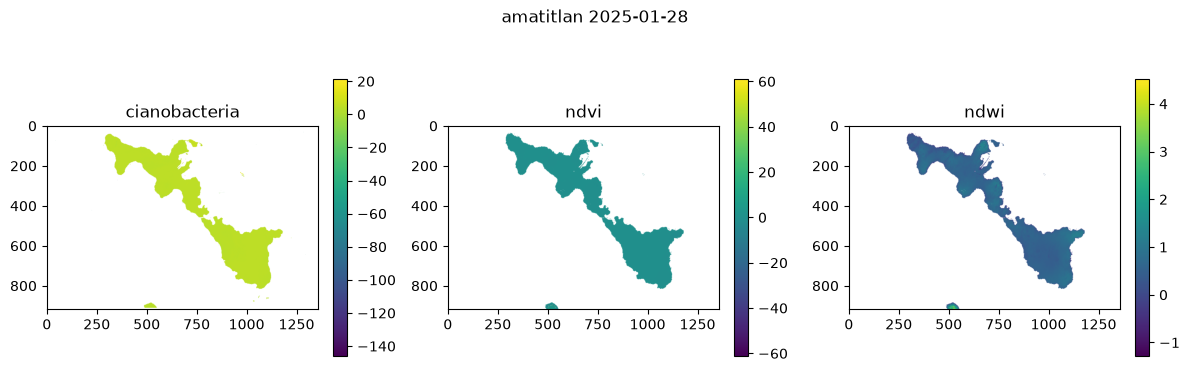

In [6]:
if EJECUTAR_DEMO:
    import matplotlib.pyplot as plt
    import rasterio

    disponibles = sorted(outputs)
    fig, axes = plt.subplots(1, len(disponibles), figsize=(4 * len(disponibles), 4), squeeze=False)
    for ax, indice in zip(axes[0], disponibles):
        path = outputs[indice]
        with rasterio.open(path) as dataset:
            array = dataset.read(1)
        im = ax.imshow(array)
        ax.set_title(indice)
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle(f"{demo_scene.lago} {demo_scene.fecha}")
    plt.tight_layout()
    plt.show()
else:
    print('Sin datos de la demo todavía.')


## 6. Calculo del lote de 22 escenas

Ya se valido la escena demostrativa. `EJECUTAR_LOTE=True` calcula los tres
indices para las 22 escenas oficiales. `FETCH_CYANO_REMOTO_LOTE=True`
porque ya se cuenta con credenciales de Sentinel Hub; en la practica no
genera peticiones nuevas porque el raster crudo de cianobacteria de cada
escena ya se habia descargado antes (ver
`data/raw/rasters/<lago>/<fecha>/cyano_ndci_l1c.tif`).

In [7]:
EJECUTAR_LOTE = True
FETCH_CYANO_REMOTO_LOTE = True

if EJECUTAR_LOTE:
    resultados = compute_indices_batch(
        list(ESCENAS_OFICIALES),
        fetch_cyano_remote=FETCH_CYANO_REMOTO_LOTE,
        confirm_batch=True,
    )
    print(f'Escenas procesadas: {len(resultados)}')
    indices_por_escena = {k: sorted(v) for k, v in resultados.items()}
    print('Índices obtenidos por escena (ejemplo):', next(iter(indices_por_escena.items())))
else:
    print('Lote omitido. Cambie EJECUTAR_LOTE=True para calcular las 22 escenas.')


Escenas procesadas: 22
Índices obtenidos por escena (ejemplo): ('amatitlan_2025-01-28', ['cianobacteria', 'ndvi', 'ndwi'])


## 7. Tabla de control de calidad

Mínimos, máximos, promedio y cobertura válida por producto, leídos
directamente de `manifest_indices.csv` (fuente única para el ejercicio 4,
según el contrato de la planificación de avances).

In [8]:
rows = validate_manifest_indices()
manifest = pd.DataFrame(rows)
numeric_cols = ['pixeles_validos', 'pixeles_lago', 'cobertura_valida_pct', 'frac_valores_atipicos']
manifest = manifest.assign(**{col: pd.to_numeric(manifest[col], errors='coerce') for col in numeric_cols})

resumen_calidad = (
    manifest.groupby('indice')[numeric_cols]
    .agg(['count', 'mean', 'min', 'max'])
)
display(resumen_calidad)
print('Filas por quality_flag:')
display(manifest.groupby(['indice', 'quality_flag']).size().rename('n').reset_index())
print('Escenas con advertencia (cobertura parcial oficial o valores atípicos frecuentes):')
display(manifest[manifest['quality_flag'].isin(['cobertura_parcial_oficial', 'revisar_valores_atipicos'])]
        [['lago', 'fecha', 'indice', 'frac_valores_atipicos', 'quality_flag']])


pixeles_validos                                 pixeles_lago  \
                        count           mean     min      max        count   
indice                                                                       
cianobacteria              22  682099.000000  139711  1236717           22   
ndvi                       22  685872.045455  133866  1232096           22   
ndwi                       22  687181.590909  133866  1232097           22   

                                              cobertura_valida_pct             \
                        mean     min      max                count       mean   
indice                                                                          
cianobacteria  687229.045455  133866  1232097                   22  18.442518   
ndvi           687229.045455  133866  1232097                   22  18.503818   
ndwi           687229.045455  133866  1232097                   22  18.531000   

                                frac_valores_atipicos                    \
                   min      max                 count      mean     min   
indice                                                                    
cianobacteria  11.2027  25.5996                    22  0.069459  0.0001   
ndvi           10.7340  25.5039                    22  0.037436  0.0000   
ndwi           10.7340  25.5039                    22  0.042932  0.0000   

                       
                  max  
indice                 
cianobacteria  0.3868  
ndvi           0.2787  
ndwi           0.3067

Filas por quality_flag:


,indice,quality_flag,n
0,cianobacteria,calculado,15
1,cianobacteria,cobertura_parcial_oficial,1
2,cianobacteria,revisar_valores_atipicos,6
3,ndvi,calculado,18
4,ndvi,cobertura_parcial_oficial,1
5,ndvi,revisar_valores_atipicos,3
6,ndwi,calculado,18
7,ndwi,cobertura_parcial_oficial,1
8,ndwi,revisar_valores_atipicos,3


Escenas con advertencia (cobertura parcial oficial o valores atípicos frecuentes):


,lago,fecha,indice,frac_valores_atipicos,quality_flag
18,amatitlan,2026-02-07,ndvi,0.0771,cobertura_parcial_oficial
19,amatitlan,2026-02-07,ndwi,0.0771,cobertura_parcial_oficial
20,amatitlan,2026-02-07,cianobacteria,0.0005,cobertura_parcial_oficial
33,atitlan,2025-01-18,ndvi,0.2787,revisar_valores_atipicos
34,atitlan,2025-01-18,ndwi,0.3067,revisar_valores_atipicos
35,atitlan,2025-01-18,cianobacteria,0.3360,revisar_valores_atipicos
44,atitlan,2025-07-17,cianobacteria,0.1475,revisar_valores_atipicos
45,atitlan,2025-11-21,ndvi,0.1544,revisar_valores_atipicos
46,atitlan,2025-11-21,ndwi,0.1631,revisar_valores_atipicos
47,atitlan,2025-11-21,cianobacteria,0.3868,revisar_valores_atipicos


## 8. Resultado del ejercicio 3 y entrega al ejercicio 4

`manifest_indices.csv` contiene una fila por lago, fecha e indice con: ruta
del GeoTIFF de una sola banda `float32`, metodo, version de formula,
unidad, CRS, resolucion, pixeles validos, cobertura y fraccion de valores
atipicos. El ejercicio 4 debe leer unicamente este archivo (no rutas
propias) para el analisis temporal.

**Estado actual:** NDVI, NDWI y cianobacteria estan calculados con datos
reales para las 22 escenas (66 de 66 filas), sin ninguna fila en
`pendiente_calculo`.

**Limitaciones explicitas:**

- Mientras no exista el contorno oficial (GeoJSON) del lago, la mascara
  espacial usada para NDVI/NDWI es la clase "agua" de la banda SCL dentro
  del bbox de consulta, no un poligono fijo del lago. Debe reemplazarse por
  la interseccion con el GeoJSON oficial en cuanto este disponible.
- La escena `amatitlan 2026-02-07` conserva su advertencia de cobertura
  parcial oficial (~57.1 %) en los tres indices y no debe compararse como
  si tuviera la misma confiabilidad que una escena completa.
- Tres fechas de Atitlan (`2025-01-18`, `2025-11-21`, `2026-02-12`) quedan
  marcadas `revisar_valores_atipicos` en NDVI y NDWI: una fraccion
  inusualmente alta de pixeles (13-31 %) cae fuera del rango teorico [-1,1]
  por reflectancia casi nula/negativa en aguas profundas, no por una senal
  ambiental real. Ver `codebook.md` para el detalle.
- Cianobacteria tiene su propio conjunto de fechas atipicas en Atitlan:
  ademas de las tres anteriores, tambien `2025-07-17`, `2025-12-29` y
  `2026-07-22` quedan marcadas `revisar_valores_atipicos` (mas del 10 % de
  pixeles fuera del rango de referencia 0-500 ug/L del script, casi
  siempre valores negativos del polinomio sobre agua muy clara). En total
  6 de las 11 fechas de Atitlan llevan esta advertencia en cianobacteria;
  sus promedios deben tratarse con cautela en el ejercicio 4.
- La caja de Atitlan a 10 m de resolucion supera el limite de 2500 px por
  lado que acepta la Process API de Sentinel Hub en modo sincrono. Para
  esas 11 escenas el raster crudo de cianobacteria se pide a una
  resolucion efectiva algo mas gruesa (manteniendo la relacion de aspecto)
  y se realinea despues a la rejilla comun de 10 m, asi que el GeoTIFF
  exportado no cambia de resolucion, solo el insumo crudo intermedio.